Niklas Fritz, 421248

## Task 1: Analysing Pre-trained Word Embeddings (6 Points)

In [3]:
from tutorial2_task1 import load_glove_model

model = load_glove_model("glove.6B.50d.txt")
vocab = list(model.keys())

print(f"{len(vocab)} words found with {len(model['the'])} vector size!")

400000 words found with 50 vector size!


### Finding Distance Between Words

Let's explore whether the pre-trained word embeddings accurately reflect the intuitive similarity between words. For instance, we would expect the word "dog" to be more similar to "cat" (as both are pet animals) than to a word like "ball." We can verify this assumption using the word embeddings.

In [4]:
from tutorial2_task1 import cosine_distance

d_dog_cat = cosine_distance(model["dog"], model["cat"])
d_dog_ball = cosine_distance(model["dog"], model["ball"])

print(f"Distance between dog and cat: {d_dog_cat}")
print(f"Distance between dog and bear: {d_dog_ball}")

Distance between dog and cat: 0.07819956541061401
Distance between dog and bear: 0.5058270692825317


Having established the ability to measure the distance between two words using their word embeddings, we can now extend this approach to compare a specific word against all words in our pre-trained model. For instance, which words are most similar to "awesome" in this context? Let's find out:

In [5]:
from tutorial2_task1 import most_similar
from tutorial2_task1 import cosine_distance, euclidean_distance

similar_words_cosine = most_similar(model["awesome"], model, cosine_distance)
similar_words_euclidean = most_similar(model["awesome"], model, euclidean_distance)

print("Cosine distance:")
print(similar_words_cosine)

print("Euclidean distance:")
print(similar_words_euclidean)

Cosine distance:
[('awesome', np.float32(-1.1920929e-07)), ('unbelievable', np.float32(0.13613915)), ('amazing', np.float32(0.13793355)), ('incredible', np.float32(0.15291148)), ('fantastic', np.float32(0.1940301)), ('marvelous', np.float32(0.21001011)), ('terrific', np.float32(0.21978825)), ('phenomenal', np.float32(0.2554978)), ('truly', np.float32(0.25664538)), ('luck', np.float32(0.2759173))]
Euclidean distance:
[('awesome', np.float32(0.0)), ('amazing', np.float32(2.2457943)), ('unbelievable', np.float32(2.3429704)), ('incredible', np.float32(2.348345)), ('marvelous', np.float32(2.417427)), ('terrific', np.float32(2.545364)), ('fantastic', np.float32(2.595255)), ('phenomenal', np.float32(2.8482318)), ('marvellous', np.float32(2.8635528)), ('luck', np.float32(2.9113293))]


### Compare Similarity Between Groups of Words

In [6]:
common_words = [
    # colors
    "red", "orange", "yellow", "green", "blue", "purple",
    "pink", "brown", "black", "grey", "white", "violet", 
    # months
    "january", "february", "march", "april", "may", "june", 
    "july", "august", "september", "october", "november", "december",
]

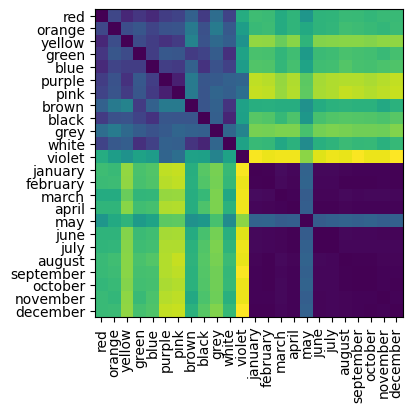

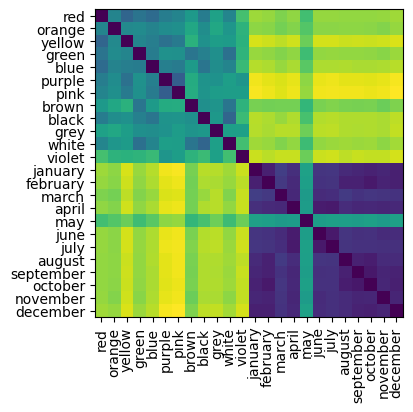

In [7]:
from tutorial2_task1 import show_similarities

show_similarities(common_words, model, cosine_distance)
show_similarities(common_words, model, euclidean_distance)

Do the word embeddings agree with you assumption of relatedness between words?

Your answer: 

Yes they do. One observes, that all months are highly related. The colors show nicely that colors which are related (such as black and white) show stronger similarity. The moth may is extraordinary, because "may" could also be interpretated as the verb "may".

### Vector Arithmetic for Analogy Solving

What happens if we subtract 'man' from 'king'? This is like asking the model to take the concept of 'king', and remove 'maleness' from it. What you're left with (in theory) is the concept of royalty or a ruler without the gender association. Then, by adding the vector for 'woman', you're essentially asking the model to provide a word that is similar to a 'king', but with a feminine aspect.

That´s really cool to see :)

In [8]:
import numpy as np
vec = model["king"] - model["man"] + model["woman"]
similar_words = most_similar(vec, model, euclidean_distance, ignore_vec=np.array([model["king"]]))

print(similar_words)
print(most_similar(model["king"], model, euclidean_distance))

[('queen', np.float32(2.8391209)), ('prince', np.float32(3.661004)), ('elizabeth', np.float32(3.715252)), ('daughter', np.float32(3.8317876)), ('widow', np.float32(3.8493776)), ('throne', np.float32(3.8837435)), ('monarch', np.float32(3.8925035)), ('cousin', np.float32(3.9533188)), ('eldest', np.float32(3.962192)), ('princess', np.float32(3.9624627))]
[('king', np.float32(0.0)), ('prince', np.float32(3.1179736)), ('queen', np.float32(3.477756)), ('uncle', np.float32(3.5069308)), ('ii', np.float32(3.5766704)), ('grandson', np.float32(3.691133)), ('brother', np.float32(3.6961105)), ('kingdom', np.float32(3.726456)), ('son', np.float32(3.7550519)), ('nephew', np.float32(3.7816255))]


More analogies:

In [11]:
from tutorial2_task1 import analogies


print(analogies("man", "king", "woman", model))
print(analogies("brazil", "pele", "argentina", model))
print(analogies("america", "washington", "germany", model))
print(analogies("boy", "father", "girl", model))
print(analogies("tennis", "ball", "rugby", model))
print(analogies("tennis", "racket", "hockey", model))
print(analogies("france", "paris", "germany", model))  
print(analogies("italy", "rome", "spain", model))     
print(analogies("run", "running", "swim", model)) 
print(analogies("walk", "walking", "crawl", model))
print(analogies("germany", "euro", "usa", model))       
print(analogies("january", "june", "february", model))


queen
maradona
berlin
mother
giggs
pucks
berlin
juan
swimming
crawling
nz
april


## Task 2 (Computing Word Embeddings - Word2Vec (12 points)

### Preparing Training Set

In [1]:
from tutorial2_task2 import tokenize

tokens = tokenize("tutorial2.txt")
print(tokens)
print(tokens[0:10])

['the', 'stand', 'up', 'was', 'by', 'far', 'the', 'best', 'one', 'the', 'comedy', 'special', 'was', 'horrible', 'this', 'movie', 'also', 'has', 'a', 'very', 'good', 'ending', 'the', 'ending', 'was', 'sorry', 'as', 'i', 'just', 'did', 'not', 'care', 'for', 'the', 'characters', 'the', 'plot', 'is', 'tight', 'and', 'the', 'acting', 'is', 'flawless', 'the', 'plot', 'is', 'predictable', 'and', 'the', 'movie', 'is', 'long', 'good', 'historical', 'drama', 'which', 'is', 'very', 'educational', 'and', 'entertaining', 'it', 'was', 'entirely', 'over', 'dramatic', 'and', 'boring', 'the', 'romance', 'of', 'the', 'movie', 'is', 'good', 'and', 'nicely', 'presented', 'it', 'was', 'the', 'most', 'terrible', 'romance', 'movie', 'i', 'had', 'ever', 'watched', 'movie', 'has', 'a', 'unique', 'science', 'fiction', 'element', 'which', 'makes', 'it', 'hilarious', 'the', 'old', 'science', 'fiction', 'trope', 'is', 'overused', 'and', 'stale', 'this', 'movie', 'is', 'rich', 'with', 'action', 'and', 'gore', 'to',

In [2]:
from tutorial2_task2 import generate_training_data

context_window_size = 1

center_words, context_words = generate_training_data(tokens, context_window_size=context_window_size)

print(center_words, context_words)

['stand', 'up', 'was', 'by', 'far', 'the', 'best', 'one', 'the', 'comedy', 'special', 'was', 'horrible', 'this', 'movie', 'also', 'has', 'a', 'very', 'good', 'ending', 'the', 'ending', 'was', 'sorry', 'as', 'i', 'just', 'did', 'not', 'care', 'for', 'the', 'characters', 'the', 'plot', 'is', 'tight', 'and', 'the', 'acting', 'is', 'flawless', 'the', 'plot', 'is', 'predictable', 'and', 'the', 'movie', 'is', 'long', 'good', 'historical', 'drama', 'which', 'is', 'very', 'educational', 'and', 'entertaining', 'it', 'was', 'entirely', 'over', 'dramatic', 'and', 'boring', 'the', 'romance', 'of', 'the', 'movie', 'is', 'good', 'and', 'nicely', 'presented', 'it', 'was', 'the', 'most', 'terrible', 'romance', 'movie', 'i', 'had', 'ever', 'watched', 'movie', 'has', 'a', 'unique', 'science', 'fiction', 'element', 'which', 'makes', 'it', 'hilarious', 'the', 'old', 'science', 'fiction', 'trope', 'is', 'overused', 'and', 'stale', 'this', 'movie', 'is', 'rich', 'with', 'action', 'and', 'gore', 'to', 'make'

#### Train the following CBOW and SkipGram models by completing their 'forward' functions. Use appropriate activation functions wherever necessary.

In [3]:
import torch
import torch.optim as optim

from tutorial2_task2 import generate_mappings

vocabulary, word2id, id2word = generate_mappings(tokens)

# defining hyperparameters
embedding_dim = 50
num_epochs = 200
context_size = 2 * context_window_size


##### Training CBOW

In [4]:
from tutorial2_task2 import CBOW, train_word2vec

cbow_inputs = torch.tensor([[word2id[w] for w in row] for row in context_words])
cbow_targets = torch.tensor([[word2id[w]] for w in center_words])

cbow_model = CBOW(len(vocabulary), context_size, embedding_dim)
cbow_loss = train_word2vec(cbow_model, cbow_inputs, cbow_targets, num_epochs)
print(cbow_loss)

[1104.85671210289, 983.2824128866196, 874.3773483037949, 776.9289639294147, 686.0253237783909, 597.9470402151346, 510.5194259881973, 424.63073921203613, 342.7714883610606, 268.63622776418924, 206.3567268922925, 158.1856297068298, 123.76470994576812, 100.47697493433952, 84.876803599298, 74.31660647504032, 66.98794141598046, 61.63509001582861, 57.54360789991915, 54.32521529868245, 51.74509885907173, 49.55346658453345, 47.7730171661824, 46.15683191455901, 44.74576582480222, 43.54419640265405, 42.4544463288039, 41.46812083479017, 40.60753726866096, 39.759834616445005, 39.02075153402984, 38.3250825740397, 37.70048754289746, 37.10509036341682, 36.52240647934377, 36.03099599573761, 35.52866952074692, 35.08035030728206, 34.590424907859415, 34.17584290681407, 33.79888556338847, 33.427661722991616, 33.059919234365225, 32.72017616359517, 32.419475723057985, 32.11186980782077, 31.801624909741804, 31.541533422656357, 31.271392000140622, 31.00700709875673, 30.789285709615797, 30.53342025191523, 30.3

##### Training SkipGram

In [5]:
from tutorial2_task2 import SkipGram, train_word2vec

skipgram_inputs = cbow_targets
skipgram_targets = cbow_inputs

skipgram_model = SkipGram(len(vocabulary), context_size, embedding_dim)
skipgram_loss = train_word2vec(skipgram_model, skipgram_inputs, skipgram_targets, num_epochs=num_epochs)

ValueError: Expected input batch_size (1) to match target batch_size (2).

##### Comparing Training Performance

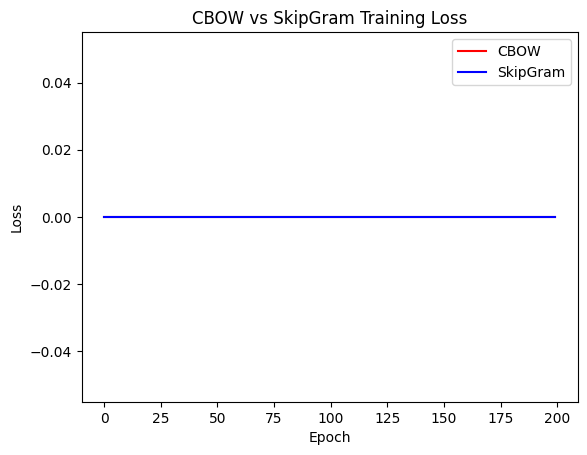

In [17]:
from tutorial2_task2 import plot_loss

plot_loss(
    'CBOW vs SkipGram Training Loss', 
    [
        (cbow_loss, "CBOW", "r"), 
        (skipgram_loss, "SkipGram", "b"),
    ]
)

#### Retrain Using a Larger Context Size

In [ ]:
# TODO: choose one and comment the other
model_cls = CBOW
# model_cls = SkipGram

context_window_size = 2
context_size = 2 * context_window_size

center_words, context_words = generate_training_data(tokens, context_window_size=context_window_size)

context_words_idx = torch.tensor([[word2id[w] for w in row] for row in context_words])
center_words_idx = torch.tensor([[word2id[w]] for w in center_words])

model = model_cls(vocab_size=len(vocabulary), context_size=context_size, embedding_dim=embedding_dim)

if isinstance(model, CBOW):
    inputs = context_words_idx
    targets = center_words_idx

if isinstance(model, SkipGram):
    inputs = center_words_idx
    targets = context_words_idx
    
loss = train_word2vec(model, inputs, targets, num_epochs=num_epochs)

In [ ]:
from tutorial2_task2 import plot_loss

plot_loss(
    "Performance", 
    [
        (loss, "model w/ higher context", "k"), 
        (cbow_loss, "CBOW", "r"), 
        (skipgram_loss, "SkipGram", "b"),
    ]
)

Does the context window affect the performance of the model? Explain in not more than 50 words.

Your response: ...

## Making Predictions

In [ ]:
context_words = ["most", "romance"]

# Convert context words to their respective indices
context_indices = torch.tensor([word2id[word] for word in context_words])

# Get the model output
log_probs = cbow_model(context_indices)

# Find the word index with the highest probability
max_prob_idx = torch.argmax(log_probs).item()

# Find the word corresponding to the predicted index
predicted_word = id2word[max_prob_idx]

print(f"The predicted center word is '{predicted_word}'")

Now it's your turn to apply a similar approach with the SkipGram model. Complete the code below to predict the context words surrounding a given center word using the SkipGram model.

In [ ]:
center_word = "movie"

# Convert the center word to its respective index
center_indices = torch.tensor([word2id[center_word]])

# Get the model output
log_probs = skipgram_model(center_indices)

# Find the word indices with the highest probability
max_prob_idx = [torch.argmax(probs).item() for probs in log_probs]

# Find the word corresponding to the predicted index
predicted_words = [id2word[id] for id in max_prob_idx]

print(f"The predicted context words are {predicted_words}")

### Task 3: Implementing RNN-LSTM classifier (6 points)

Create a moview review dataset having all the positive and negative reviews from file 'tutorial2.txt':

In [ ]:
from tutorial2_task3 import load_training_data

words, targets = load_training_data("tutorial2.txt")

print(words[0], targets[0])

Encode and pad the input words.

In [ ]:
from tutorial2_task1 import load_glove_model
from tutorial2_task3 import generate_mappings, encode_and_pad

embeddings = load_glove_model("glove.6B.50d.txt")
vocabulary, word2id, id2word = generate_mappings(embeddings)

features = encode_and_pad(words, word2id, 20)

print(features[0])

Split the dataset into train (80%) and test (20%):

In [ ]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    # TODO
)

Train a simple RNN-LSTM classifier:

In [ ]:
from tutorial2_task3 import train

embeddings_tensor = torch.tensor(list(embeddings.values()))

train(x_train, y_train, num_epochs=50, embeddings=embeddings_tensor)

In [ ]:
# TODO: Plot training performance (loss, accuracy)

In [ ]:
# TODO: Get test accuracy

### Task 4 Bert Embedding


In [ ]:
# Import necessary libraries
import numpy as np
import pandas as pd
from sentence_transformers import SentenceTransformer
from sklearn.decomposition import PCA
from sklearn.metrics import DistanceMetric
import matplotlib.pyplot as plt
import matplotlib as mpl

# 1. Load the resume dataset (resumes_train.csv)
# TODO: Read the CSV file and store it in a DataFrame named 'df_resume'
# HINT: Use pd.read_csv() to load the file

# Display the first few rows of the dataset
# TODO: Display the head of the dataframe to inspect the structure
# HINT: Use df_resume.head()



In [ ]:
# 2. Encode the resumes using a pre-trained model
# TODO: Initialize the SentenceTransformer model (use 'all-MiniLM-L6-v2') and encode the 'resume' column
# HINT: Use model.encode() to encode the resumes and store them in 'embedding_arr'

# TODO: Print the shape of 'embedding_arr' to check the dimensionality of the embeddings



In [ ]:
# 3. Apply PCA to reduce dimensionality
# TODO: Apply PCA to reduce the embedding dimension to 2 components
# HINT: Use PCA(n_components=2) and fit it to 'embedding_arr'

# TODO: Print the explained variance ratio of the first two components
# HINT: Use pca.explained_variance_ratio_

# 4. Visualize the resumes using PCA components
plt.figure(figsize=(8, 6))
plt.rcParams.update({'font.size': 16})
plt.grid()

c = 0
cmap = mpl.colormaps['jet']

# TODO: Loop through each unique role in df_resume['role'], extract the corresponding embeddings, and plot them
# HINT: Use plt.scatter() to plot the PCA-transformed embeddings for each role

plt.legend(bbox_to_anchor=(1.05, 0.9))
plt.xticks(rotation=45)
plt.xlabel("PC 1")
plt.ylabel("PC 2")
plt.show()


In [ ]:

# 5. Define a job query
# TODO: Define a query as a string. This query represents the job you are searching for
# EXAMPLE: "Data Engineer with Apache Airflow experience"

# 6. Encode the job query using the same model
# TODO: Encode the job query using the SentenceTransformer model and store the result in 'query_embedding'




In [ ]:
# 7. Compute the distances between the query and resumes
# TODO: Initialize the distance metric (Euclidean distance) and compute the distances between the query and each resume
# HINT: Use DistanceMetric.get_metric() and pairwise() to compute the distances

# TODO: Sort the resumes based on the distances and store the indices of the sorted array in 'idist_arr_sorted'
# HINT: Use np.argsort()

# 8. Display the top 10 most relevant roles
# TODO: Print the top 10 most relevant roles based on the sorted distances
# HINT: Use df_resume['role'].iloc[] with the sorted indices

# 9. Display the most relevant resume
# TODO: Print the resume text that is the closest match to the query
# HINT: Use df_resume['resume'].iloc[] with the sorted indices